# Packages

In [22]:
%load_ext autoreload
%autoreload 2

import sys
import os
import json

import networkx as nx
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import plotly.graph_objects as go

from grngen import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Pipeline

Loaded graph from ../../data/graphs/human_trrust_g.graphml.
Loaded graph stats from ../../data/graphs/human_trrust_stat.json.
Loaded graph motif counts from ../../data/graphs/human_trrust_motifs.json.
Best graph_id for dataset human_trrust: 34


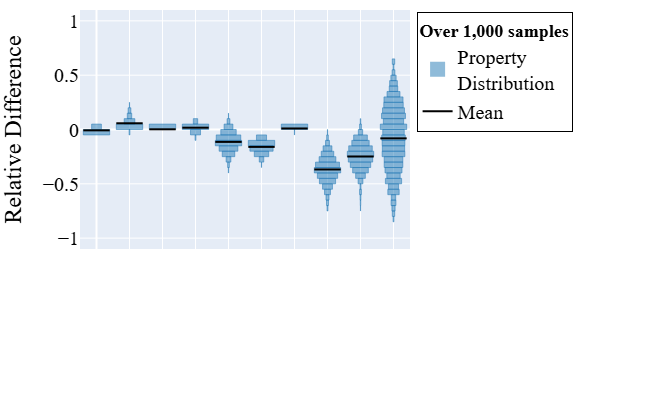

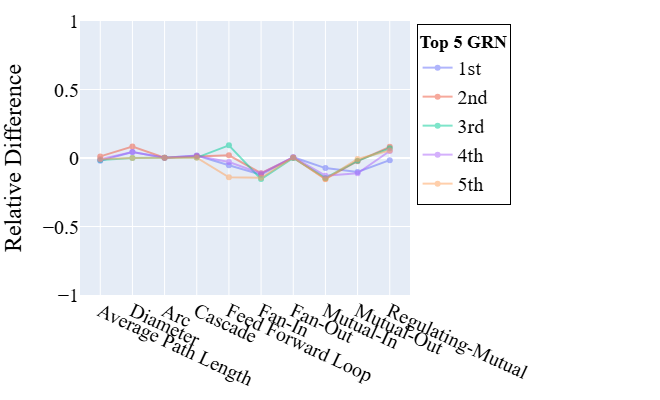

Chargement des données depuis ../../data/random_graphs/human_trrust/human_trrust_results.parquet...


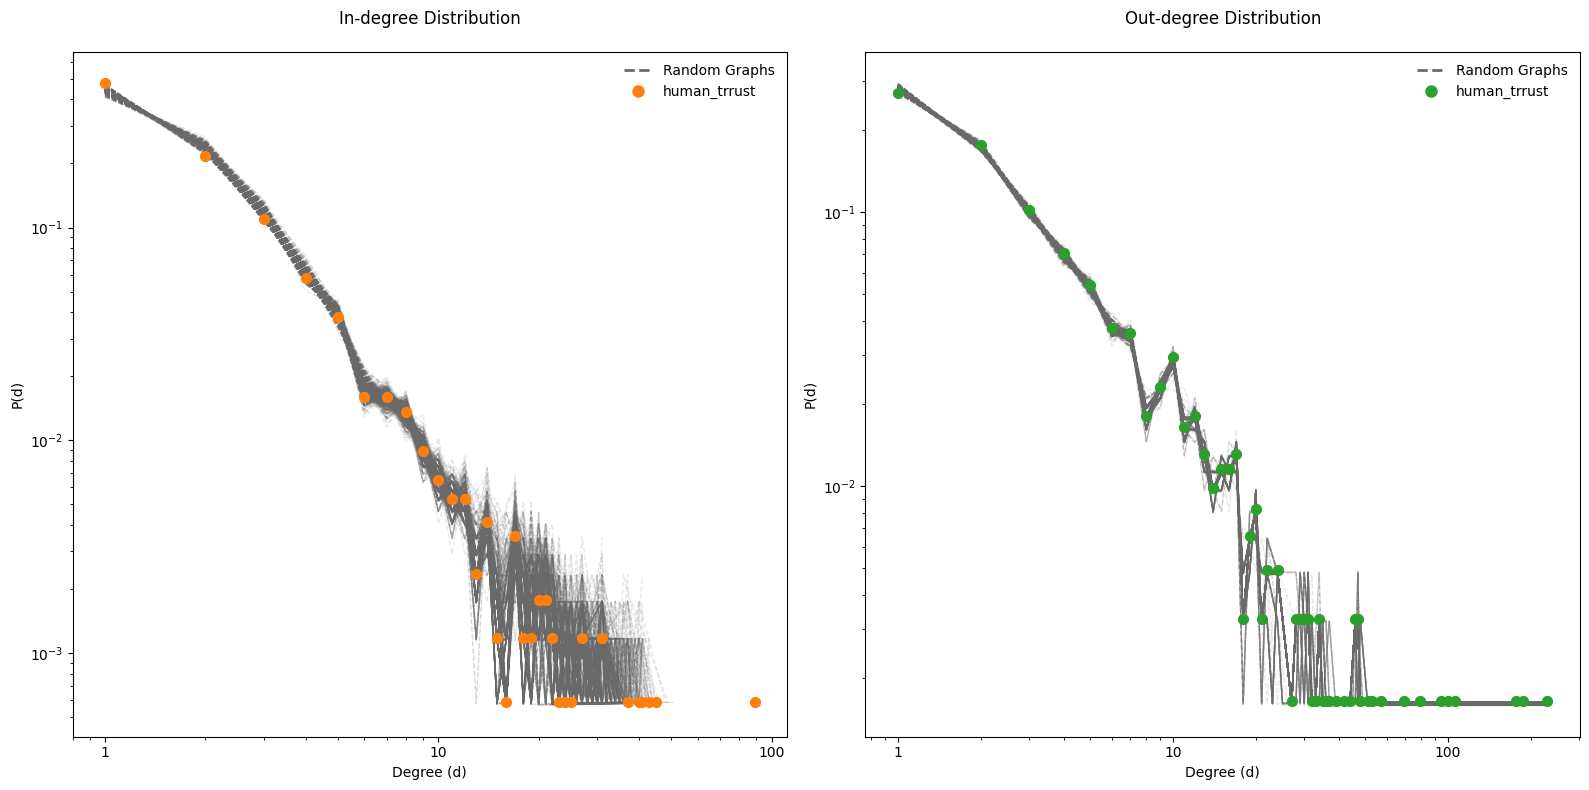

In [23]:
specie = 'human_trrust'

properties_to_keep = [
    'graph_id',
    'avg_path_dir', 'diameter',
    'nb_edges', 
    'Cascade',
    'FFL', 'Fan-In', 'Fan-Out',
    'Mutual-In', 'Mutual-Out',
    'Regulating-Mutual'
]

idces_list = {}


# Load ground truth
input_dir = f"../../data/graphs/"
ground_truth_graph, ground_truth_stat, ground_truth_motifs = load_graphs(input_dir+specie)
ground_truth_all_stats = ground_truth_stat | ground_truth_motifs

# Load random data from Parquet
output_dir = f"../../data/random_graphs/{specie}"
parquet_path = f'{output_dir}/{specie}_results.parquet'
df_random = pd.read_parquet(parquet_path, columns=properties_to_keep)

# Computing errors
gt_prop = {
    key: value 
    for key, value in ground_truth_all_stats.items()
    if key in properties_to_keep
}

# Computing errors
df_errors = compute_relative_error(df_random, gt_prop)

# Select best graph
idces_list[specie] = get_best_indices(df_errors, n_top=5)
print(f'Best graph_id for dataset {specie}: {df_errors["graph_id"][idces_list[specie][0]]}')

# Prepare data
df = df_errors.drop(['total_error', 'graph_id'], axis=1)

# Define labels
label_mapping = {
    'avg_path_dir': "Average Path Length", 
    'diameter': "Diameter",
    'nb_edges': "Arc", 
    'Cascade': "Cascade", 
    'FFL': "Feed Forward Loop", 
    'Fan-In': "Fan-In",
    'Fan-Out': "Fan-Out", 
    'Mutual-In': "Mutual-In",
    'Mutual-Out': "Mutual-Out",
    'Regulating-Mutual': "Regulating-Mutual",
}

fig1 = plot_histogram_distribution(
    df,
    label_mapping=label_mapping,
    n_bins=40
)
fig1.show()


fig2 = plot_best_profiles(
    df_errors, 
    idces_list[specie], 
    specie, 
    label_mapping
)
fig2.show()

plot_deg_ref_vs_multi_sim(
        ground_truth_graph, 
        parquet_path,
        ref_label=specie
    )

# End